In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [27]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [28]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [29]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [30]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,Partially cloudy
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [31]:
kwh_data.describe()

,temp,humidity,windgust,winddir,cloudcover,solarradiation
count,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000,21983.000000
mean,13.414748,60.205863,16.050139,217.827658,47.738025,176.537262
std,8.779722,22.578909,9.320562,136.029381,38.837197,264.425914
min,-10.000000,8.300000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,42.300000,10.000000,90.000000,4.800000,0.000000
50%,13.000000,59.280000,13.700000,290.000000,49.100000,11.000000
75%,20.000000,77.910000,19.700000,340.000000,88.300000,298.000000
max,40.000000,100.000000,72.000000,360.000000,100.000000,1157.000000


In [32]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_1219/4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0,0,1,1
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0,1,1,1
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2,2,1,1
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2,3,1,1
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2,4,1,1
...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7


In [33]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0,0,1,1,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0,1,1,1,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2,2,1,1,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2,3,1,1,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2,4,1,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7,0.0000


In [34]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :11])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,10
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,0.662831,-0.361218,-1.662386,-1.452052,-0.234996


In [35]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,10
datetime,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890


In [36]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,6,7,8,9,10,Kwh
datetime,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121,0.0592
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731,0.0085
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890,0.0000


In [37]:
def df_to_x_y(df, size=24, predict_size=24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size - predict_size):
        row = [a for a in df_as_np[i: i+size, :11]]
        x.append(row)
        real_val = df_as_np[i + size: i + size + predict_size, 11]
        y.append(real_val)
    
    return np.array(x), np.array(y)

In [38]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24, predict_size=24)
print(x_kwh.shape, y_kwh.shape)

x_train_kwh, y_train_kwh = x_kwh[:int(0.95*len(x_kwh))], y_kwh[:int(0.95*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.95*len(x_kwh)):int(0.99*len(x_kwh))], y_kwh[int(0.95*len(y_kwh)):int(0.99*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.99*len(x_kwh)):], y_kwh[int(0.99*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape


(21935, 24, 11) (21935, 24)


((20838, 24, 11),
 (20838, 24),
 (877, 24, 11),
 (877, 24),
 (220, 24, 11),
 (220, 24))

In [39]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [40]:
input_shape = (24, 11)

inputs = Input(shape=input_shape)

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

query = cnn_out
value = cnn_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

dropout_out = Dropout(0.3)(multihead_attention_out)

dense_out = Dense(128, activation="relu")(dropout_out)

flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

# Output layer predicting 24 future kWh values
outputs = Dense(24, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │      2,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_2 │ (None, 12, 64)    │          0 │ conv1d_2[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 64)    │        256 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_3 │ (None, 6, 128)    │          0 │ conv1d_3[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 6, 128)    │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 128)    │    527,488 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 6, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 128)    │     16,512 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24)        │      3,096 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 707,352 (2.70 MB)

 Trainable params: 706,456 (2.69 MB)

 Non-trainable params: 896 (3.50 KB)

In [41]:
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
648/652 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0544 - root_mean_squared_error: 0.2212
Epoch 1: val_loss improved from inf to 0.00805, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
652/652 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0542 - root_mean_squared_error: 0.2208 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0899 - learning_rate: 0.0010
Epoch 2/40
650/652 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0126 - root_mean_squared_error: 0.1123
Epoch 2: val_loss improved from 0.00805 to 0.00746, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
652/652 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0126 - root_mean_squared_error: 0.1123 - val_loss: 0.0075 - val_root_mean_squared_error: 0.0863 - learning_rate: 0.0010
Epoch 3/40
649/652 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0097 - root_mean_squared_error: 0.0984
Epoch 3: val_loss did not improve from 0.00746
652/652 ━━━━━━━━━━━━━━━━━━━━ 8s

In [42]:
test_predictions_kwh = model_1.predict(x_test_kwh)



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


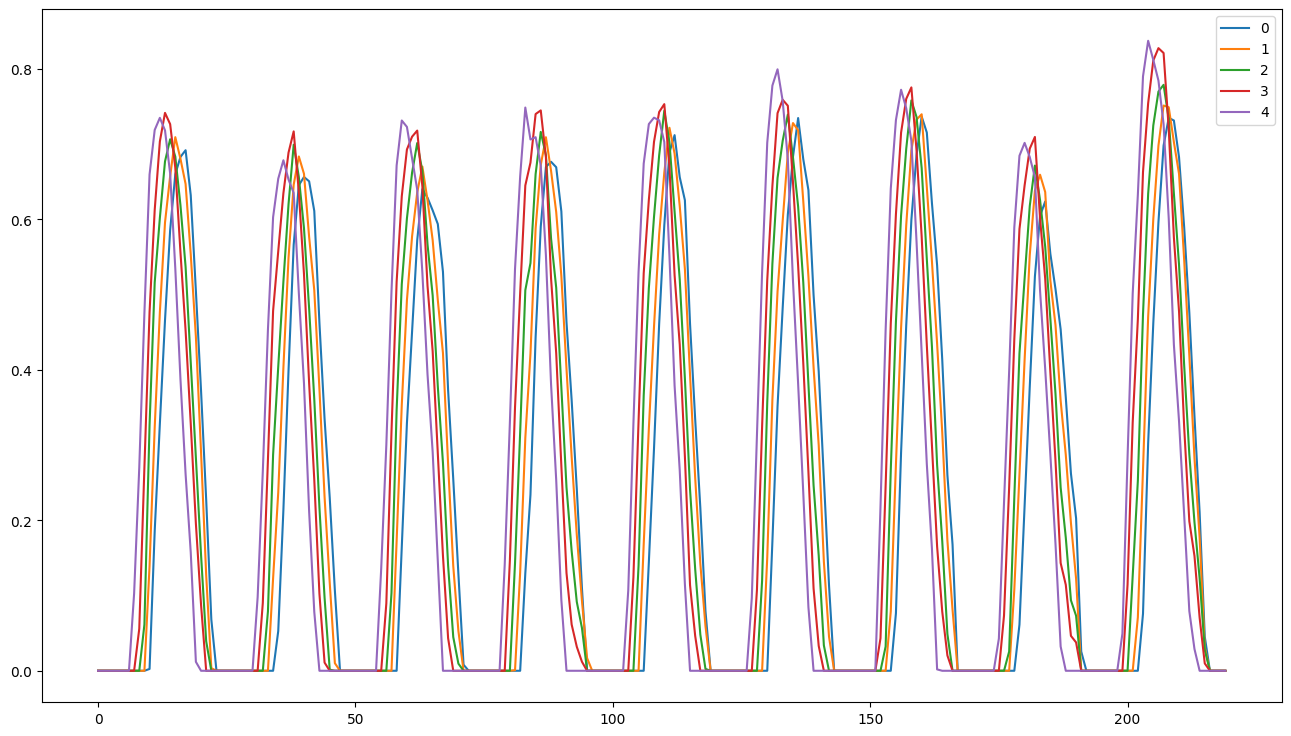

In [59]:
plt.figure(figsize=(16, 9))
for i in range(5):
    plt.plot(test_predictions_kwh[:, i], label = i)
plt.legend()


In [44]:
test_results_kwh = pd.DataFrame({
    "Real Data": y_test_kwh.flatten(),  
    "Predicted": test_predictions_kwh.flatten()  
})

In [45]:
test_results_kwh

,Real Data,Predicted
0,0.0082,0.000000
1,0.0000,0.000000
2,0.0000,0.000000
3,0.0000,0.000000
4,0.0000,0.000000
...,...,...
5275,0.2298,0.128621
5276,0.0592,0.000000
5277,0.0085,0.000000
5278,0.0000,0.000000


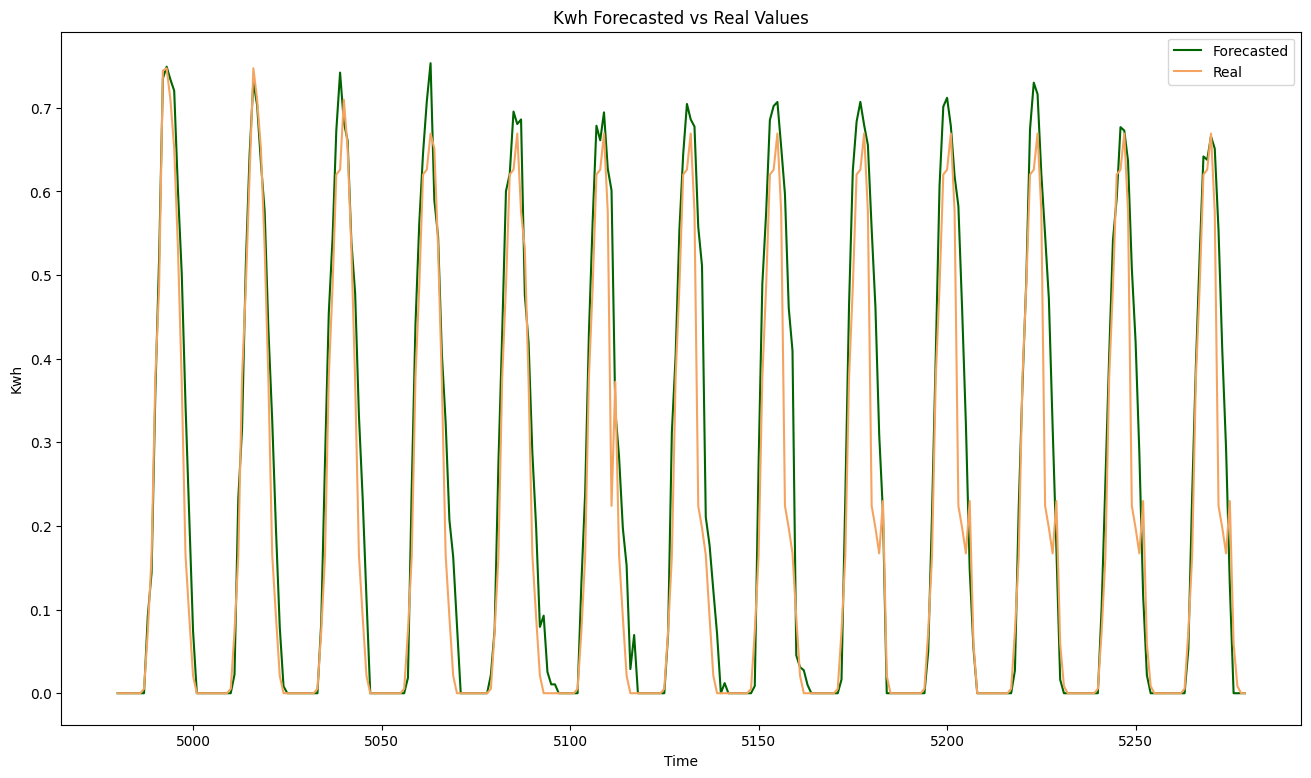

In [46]:
plt.figure(figsize=(16, 9))
sns.lineplot(x = test_results_kwh.index[-300: ], y = test_results_kwh["Predicted"][-300: ], label="Forecasted", color = 'DarkGreen')
sns.lineplot(x = test_results_kwh.index[-300: ], y = test_results_kwh["Real Data"][-300: ], label="Real", color = 'SandyBrown')
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


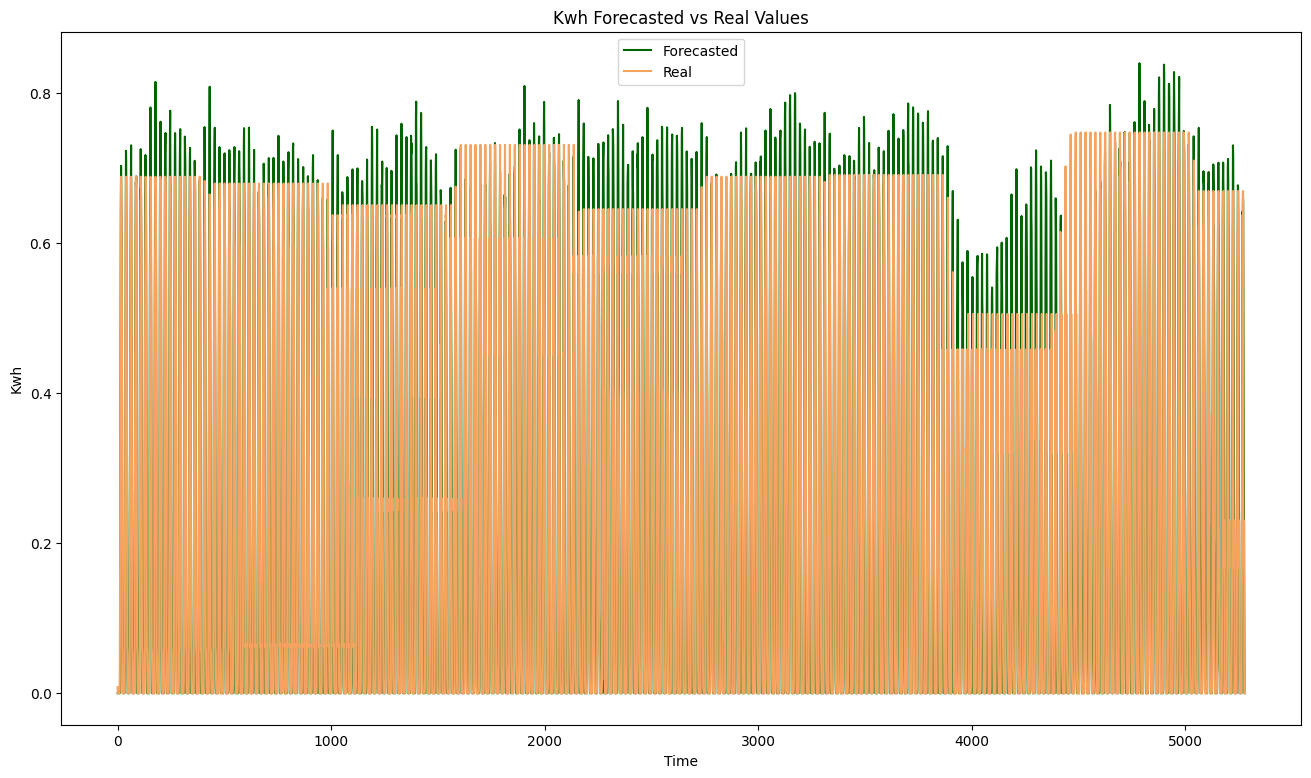

In [47]:
plt.figure(figsize=(16, 9))
sns.lineplot(x = test_results_kwh.index, y = test_results_kwh["Predicted"], label="Forecasted", color = 'DarkGreen')
sns.lineplot(x = test_results_kwh.index, y = test_results_kwh["Real Data"], label="Real", color = 'SandyBrown')
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


In [48]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Predicted"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Predicted"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

mean_real_data = test_results_kwh["Real Data"].mean()
mse_percent = (mse_kwh / mean_real_data) * 100

r_squared_kwh, mse_kwh, mse_percent   

Mean Squared Error = 0.00459 
Root Mean Squared Error = 0.06774


(0.930603651349883, 0.004588728544045902, 2.0970691833324575)

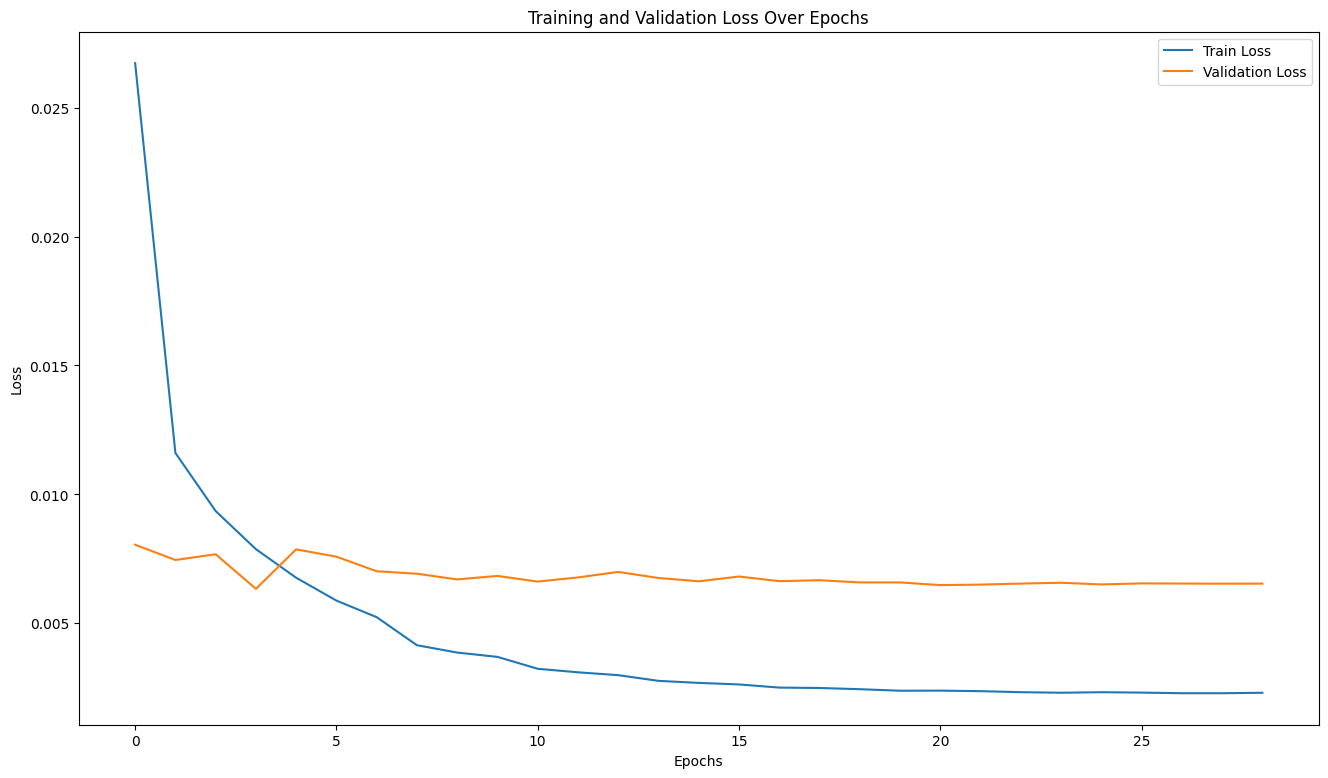

In [49]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

In [50]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_kwh)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.title("Real vs Forecasted Kwh")
plt.show()

ValueError: Could not interpret value `Val Predictions` for `y`. An entry with this name does not appear in `data`.

<Figure size 1600x900 with 0 Axes>

# Outliers with the Conditions as Input

In [ ]:
test_results_kwh['Error'] = test_results_kwh['Real Data'] - test_results_kwh['Val Predictions']
test_results_kwh

In [ ]:
Q1 = test_results_kwh['Error'].quantile(0.25)
Q3 = test_results_kwh['Error'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 8 * IQR
upper_bound = Q3 + 8 * IQR

# Find the outliers
outliers = test_results_kwh[(test_results_kwh['Error'] < lower_bound) | (test_results_kwh['Error'] > upper_bound)]
print(outliers)

In [ ]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = outliers)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [ ]:
common_index = data.index.intersection(outliers.index)

initial_df_outliers = data.loc[common_index]

initial_df_outliers

In [ ]:
initial_df_outliers['time'] = initial_df_outliers.index.time
initial_df_outliers

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['time']))
plt.xlabel('Hours in Day')
plt.ylabel("Count")
plt.title("BarPlot of Hours")
plt.show()

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['conditions']))
plt.xlabel('Conditions')
plt.ylabel("Count")
plt.title("BarPlot of Conditions in Outliers")
plt.show()